In [1]:
""" Same graphs as plot_model_diagnostics.ipynb but shows multiple modified model runs.
"""
import numpy as np
import os
import pandas as pd
import xarray as xr
from glob import glob
import matplotlib.pyplot as plt
import itertools as it
from scipy.stats import linregress
from matplotlib.cm import get_cmap 
from utils.constants import chamber_levels_complete, chamber_list_complete_dict_rev
import matplotlib.ticker as ticker
import itertools as it
from matplotlib import rcParams
from matplotlib.colors import BoundaryNorm, to_rgba
from utils.analysis import uq_get_obs, uq_get_sim, get_obs_agnpp
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 12

pft_names = ['Spruce', 'Tamarack', 'Shrub']
pft_frac = [0.36, 0.14, 0.25, 0.25]

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

chambers_ordered = {
    'amb': ['7', '6', '20', '13', '8', '17'],
    'elev': ['19', '11', '4', '16', '10']
}

xticklabels = ['TAMB', 'T0.00', 'T2.25','T4.50', 'T6.75', 'T9.00', 
               'T0.00CO2', 'T2.25CO2', 'T4.5CO2', 'T6.75CO2', 'T9.00CO2']
labs = 'abcdefghijklmnopqrstuvwxyz'

In [2]:
##########################################################################
# Collect all the data
##########################################################################
prefix_list = ['20231116', 'UQ_20231118', 'UQ_20240107', 'UQ_20240112']
name_list = ['ELM$_{default}$', 'ELM$_{default,optim}$',
             'ELM$_{nutrient,optim}$', 'ELM$_{nutrient,optim,optim}$']
color_list = ['#1b249e', '#05dbfc', '#ffa500', '#ff0000']


collection_gs = {}
collection_annual = {}

for prefix in prefix_list:
    temp_data = pd.read_csv(os.path.join(outdir, prefix, 'analysis_ts.csv'),
                                         header = [0, 1, 2, 3], index_col = 0, parse_dates=True)

    # restrict BTRAN & ZWT to growing season
    for col in temp_data.columns:
        if col[1] in ['BTRAN','ZWT']:
            temp_data.loc[(temp_data.index.month < 5) | (temp_data.index.month > 10), col] = np.nan

    # ratio of total nutrient uptake to AVAILC

    # average hummock and hollow, resample to annual
    temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
        ).apply(lambda df: df.iloc[:,0] * 0.64 + df.iloc[:,1] * 0.36)

    #filt = (temp_data.index.month >= 5) & (temp_data.index.month <= 10)
    filt = (temp_data.index.month >= 1) & (temp_data.index.month <= 12)
    # Limit to < 2021 to be consistent with Paul's data
    filt = filt & (temp_data.index.year <= 2021)
    collection_gs[prefix] = temp_data.loc[filt, :]

    temp_annual = temp_data.resample('1Y').mean()
    temp_annual.index = temp_annual.index.year
    temp_annual.columns = temp_annual.columns.reorder_levels(['variable', 'pft', 'plot'])
    temp_annual = temp_annual.stack()
    collection_annual[prefix] = temp_data.loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]

/tmp/ipykernel_3849497/3485652030.py:25: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_3849497/3485652030.py:25: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_3849497/3485652030.py:25: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_3849497/3485652030.py:25: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1


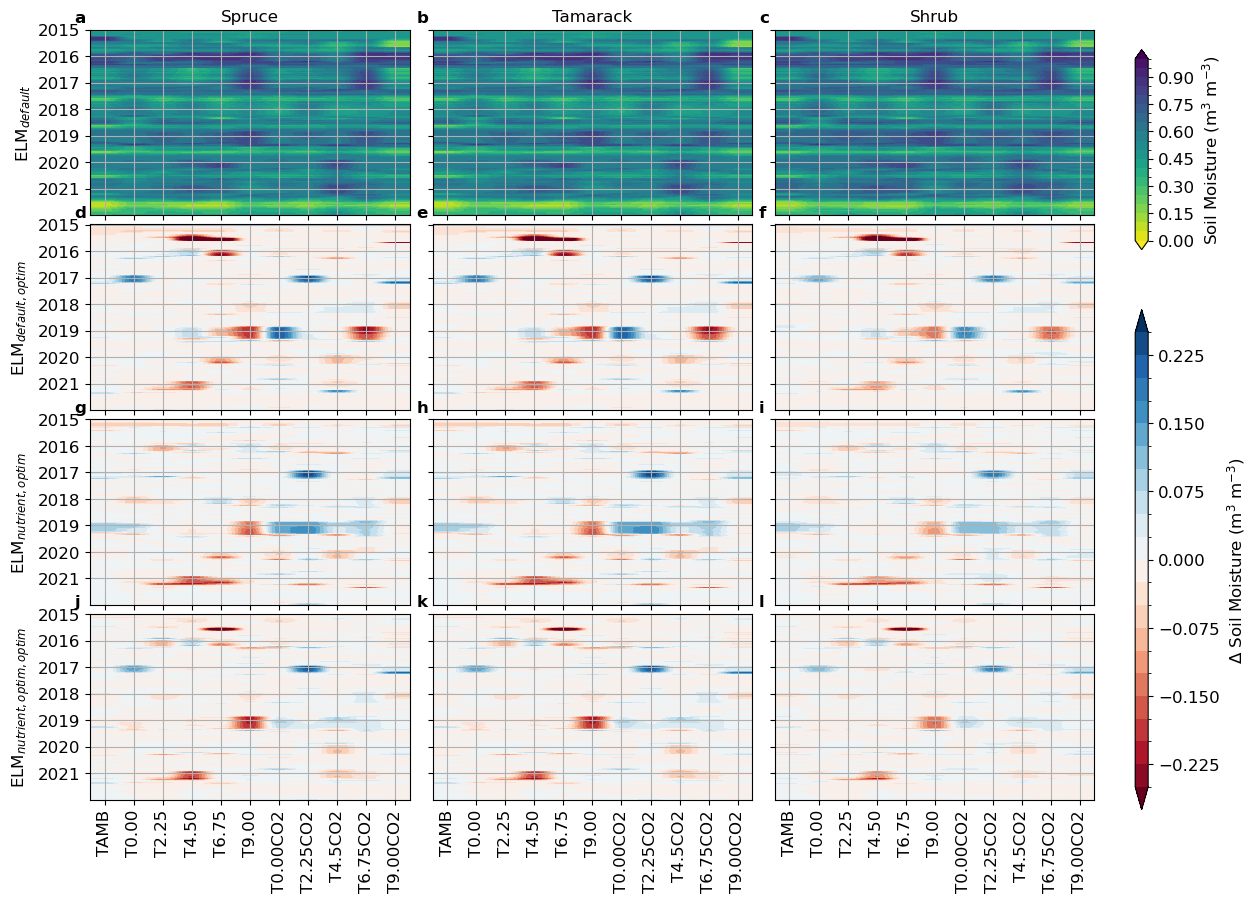

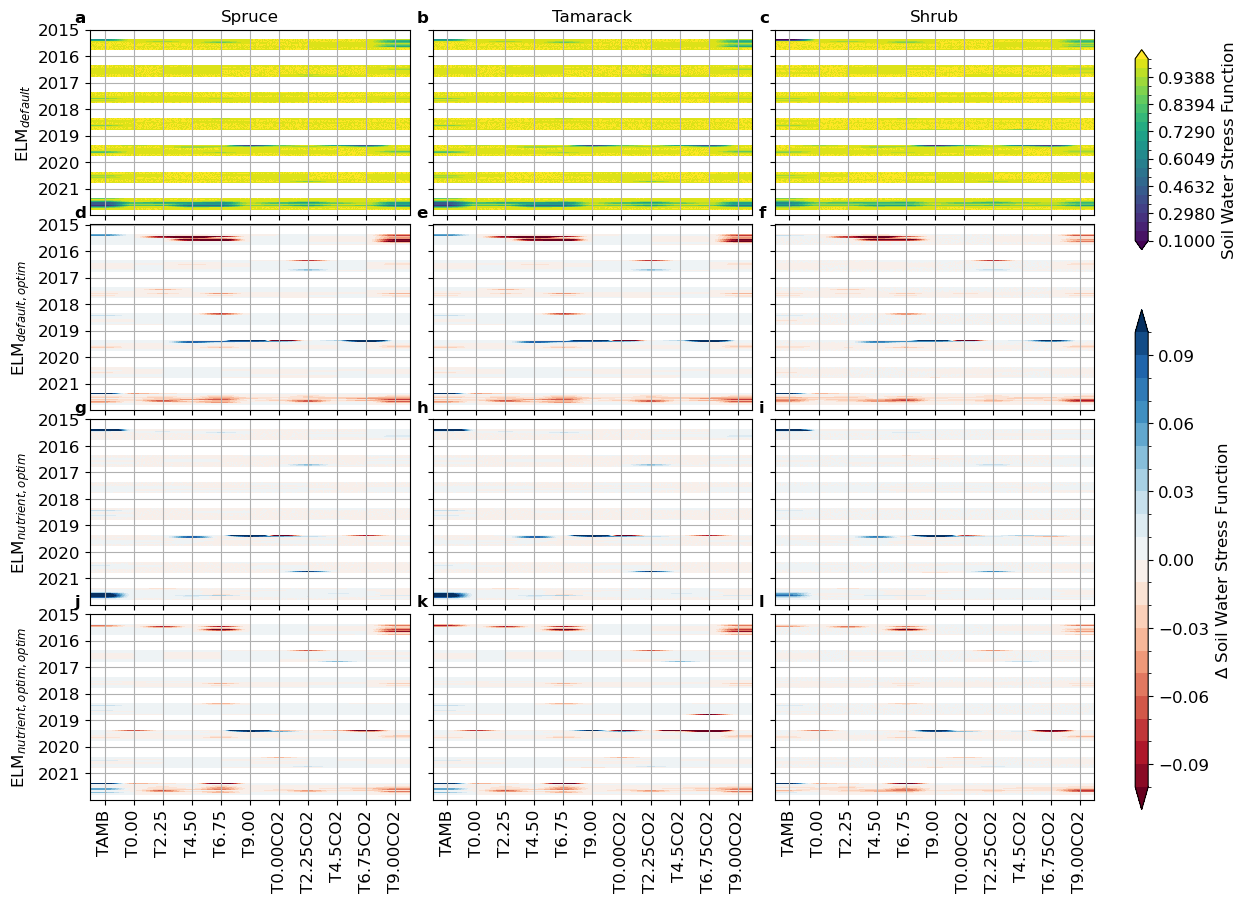

In [3]:
##########################################################################
# Water relationship
##########################################################################
for varname in ['H2OSOI_ROOTFR', 'BTRAN']:
    fig, axes = plt.subplots(4, 3, figsize = (13, 10), sharex = True)
    fig.subplots_adjust(wspace = 0.06, hspace = 0.05)
    for i, pft in enumerate(['2','3','11']):
        for j, (prefix,name) in enumerate(zip(prefix_list, name_list)):
            ax = axes[j,i]

            cpool = collection_gs[prefix].loc[:, (slice(None), varname, pft)]
            if j > 0:
                cpool = cpool - collection_gs['20231116'].loc[:, (slice(None), varname, pft)].values
                if varname == 'H2OSOI_ROOTFR':
                    levels = np.linspace(-0.25, 0.25, 21)
                else:
                    levels = np.linspace(-0.1, 0.1, 21)
                cmap = 'RdBu'
            else:
                if varname == 'H2OSOI_ROOTFR':
                    levels = np.linspace(0, 1, 21)
                    cmap = 'viridis_r'
                else:
                    levels = np.log(np.linspace(np.exp(0.1), np.exp(1), 21))
                    cmap = 'viridis'
            cf = ax.imshow(cpool.values, aspect = 2.5e-3,
                           norm = BoundaryNorm(levels, ncolors = 256, extend = 'both'),
                           cmap = cmap)
            ax.grid(True)
            plt.setp(ax.get_xticklabels(), rotation = 90)
            ax.set_xticks(range(cpool.shape[1]))
            ax.set_xticklabels(xticklabels, rotation = 90)
            if j == 0:
                ax.set_title(pft_names[i])
            ax.set_yticks(range(0, len(cpool.index), 365))
            if i == 0:
                ax.set_ylabel(name)
                ax.set_yticklabels(cpool.index.year[::365])
            else:
                ax.set_yticklabels([])

            if (j == 0) & (i == 2):
                cax = fig.add_axes([0.93, 0.66, 0.01, 0.2])
                if varname == 'H2OSOI_ROOTFR':
                    plt.colorbar(cf, cax = cax, label = 'Soil Moisture (m$^3$ m$^{-3}$)',
                                 extend = 'both')
                else:
                    plt.colorbar(cf, cax = cax, label = 'Soil Water Stress Function',
                                 extend = 'both')
            if (j == 1) & (i == 2):
                cax = fig.add_axes([0.93, 0.1, 0.01, 0.5])
                if varname == 'H2OSOI_ROOTFR':
                    plt.colorbar(cf, cax = cax, label = '$\Delta$ Soil Moisture (m$^3$ m$^{-3}$)', 
                                 extend = 'both')
                else:
                    plt.colorbar(cf, cax = cax, label = '$\Delta$ Soil Water Stress Function', 
                                 extend = 'both')
            ax.text(-0.05, 1.04, labs[j*3+i], fontdict = {'weight': 'bold'}, transform = ax.transAxes)

Text(0.5, 0, '')

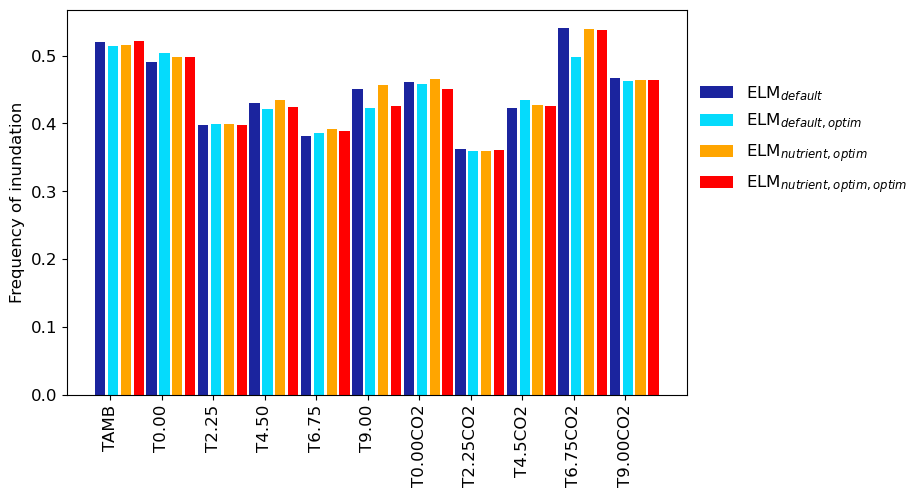

In [4]:
##########################################################################
# Column level surface water that affects moss inundation
##########################################################################
# minimum difference
fig, ax = plt.subplots(figsize = (8, 5))

b1 = [None] * len(prefix_list)
for i, (prefix, color) in enumerate(zip(prefix_list, color_list)):
    filt = (collection_gs[prefix].index.month >= 5) & (collection_gs[prefix].index.month <= 9)
    temp = collection_gs[prefix].loc[filt, (slice(None), 'H2OSFC', '0')
        ].loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
    temp.columns = temp.columns.get_level_values(0)
    freq = (temp > 0).mean(axis = 0)

    b1[i] = ax.bar(height = freq, 
                   x = np.arange(len(freq)) + (i-0.8)/len(prefix_list), 
                   width = 0.8/len(prefix_list), 
                   facecolor = color)

ax.set_ylabel('Frequency of inundation')
ax.legend(b1, name_list, frameon = False, loc = (1.01, 0.5))
ax.set_xticks(np.arange(len(freq)))
ax.set_xticklabels(xticklabels, rotation = 90)
ax.set_xlabel(None)

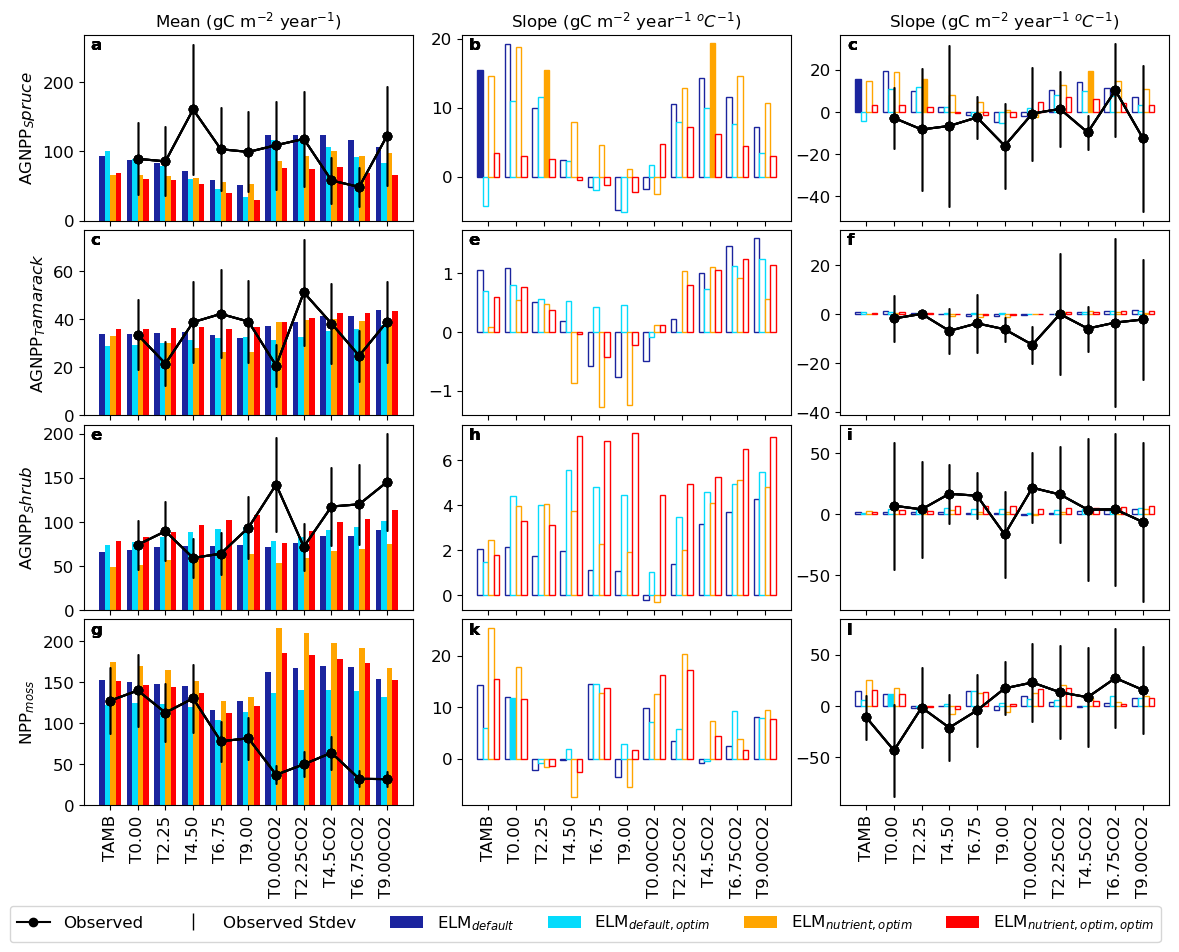

In [27]:
##########################################################################
# AGNPP (same with AGNPP)
##########################################################################
collection_obs = get_obs_agnpp()

fig, axes = plt.subplots(4, 3, figsize = (14, 10), sharex = True, sharey = False)
fig.subplots_adjust(hspace = 0.05, wspace = 0.15)
for i, (pft,name) in enumerate(zip(['2','3','11','12'],['Spruce','Tamarack','Shrub','Moss'])):

    bp = [None] * len(prefix_list)
    for p, prefix in enumerate(prefix_list):
        # Modeled
        if pft == '12':
            temp = collection_gs[prefix].loc[:, (slice(None), 'NPP', pft)
                ].loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
        else:
            temp = collection_gs[prefix].loc[:, (slice(None), 'AGNPP', pft)
                ].loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
        temp.columns = temp.columns.get_level_values(0)
        temp = temp.resample('1Y').mean()
        if pft in ['11','12']:
            # skip the year without observations
            temp.loc[temp.index.year == 2020, :] = np.nan

        temp_mean = temp.mean(axis = 0) * 365 * 86400 * pft_frac[i]

        ax = axes[i,0]
        bp[p] = ax.bar(height = temp_mean, x = np.arange(temp.shape[1]) + p*0.8/len(prefix_list),
                       width = 0.8/len(prefix_list), facecolor = color_list[p])
        ax.set_xlabel(None)
        if pft == '12':
            ax.set_ylabel('NPP$_{moss}$')
        else:
            ax.set_ylabel('AGNPP$_' + name + '$')
        if i == 0:
            ax.set_title('Mean (gC m$^{-2}$ year$^{-1}$)')
        ax.set_xticks(np.arange(temp.shape[1]) + 0.3)
        ax.set_xticklabels(xticklabels, rotation = 90)
        ax.text(0.02, 0.92, labs[2*i], transform = ax.transAxes, fontdict = {'weight': 'bold'})

        # correlation with air temperature
        temp2 = collection_gs[prefix].loc[:, (slice(None), 'TBOT', '0')
            ].loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
        temp2.columns = temp2.columns.get_level_values(0)
        temp2 = temp2.resample('1Y').mean()

        temp_slope = pd.Series(np.nan, index = temp2.columns)
        temp_slope_p = pd.Series(np.nan, index = temp2.columns)
        for col in temp2.columns:
            filt = ~(np.isnan(temp2[col]) | np.isnan(temp[col]))
            res = linregress(temp2.loc[filt, col], temp.loc[filt, col])
            temp_slope.loc[col] = res.slope * 365 * 86400 * pft_frac[i]
            temp_slope_p.loc[col] = res.pvalue
        for c in [1,2]: 
            ax = axes[i,c]
            bar_list = ax.bar(height = temp_slope,
                            x = np.arange(temp.shape[1]) + p*0.8/len(prefix_list),
                            width = 0.8/len(prefix_list), facecolor = color_list[p], 
                            edgecolor = color_list[p])
            for b,bar in enumerate(bar_list):
                if temp_slope_p.values[b] >= 0.05:
                    bar.set_facecolor('w')
            if i == 0:
                ax.set_title('Slope (gC m$^{-2}$ year$^{-1}$ $^{o}C^{-1}$)')
            ax.set_xticks(np.arange(temp.shape[1]) + 0.3)
            ax.set_xticklabels(xticklabels, rotation = 90)
            ax.text(0.02, 0.92, labs[3*i+c], transform = ax.transAxes, fontdict = {'weight': 'bold'})

        # Observation
        if pft == '12':
            varname = 'NPP_moss'
        else:
            varname = f'AGNPP_{name}'
        ax = axes[i,0]
        h, = ax.plot(np.arange(temp.shape[1]) + 0.3, 
                     collection_obs.loc[:, (varname, 'mean')], '-ok')
        h2 = ax.errorbar(np.arange(temp.shape[1]) + 0.3, collection_obs.loc[:, (varname, 'mean')], 
                    yerr = collection_obs.loc[:, (varname, 'mean_std')], lw = 0, 
                    elinewidth = 1, ecolor = 'k')
        ax = axes[i,2]
        h, = ax.plot(np.arange(temp.shape[1]) + 0.3, 
                     collection_obs.loc[:, (varname, 'slope')], '-ok')
        ax.errorbar(np.arange(temp.shape[1]) + 0.3, collection_obs.loc[:, (varname, 'slope')], 
                    yerr = collection_obs.loc[:, (varname, 'slope_std')], lw = 0, 
                    elinewidth = 1, ecolor = 'k')

    if i == 3:
        ax.legend([h, h2] + bp, ['Observed', 'Observed Stdev'] + name_list, loc='upper right', 
                  ncol = 6, bbox_to_anchor = (1, -0.5))

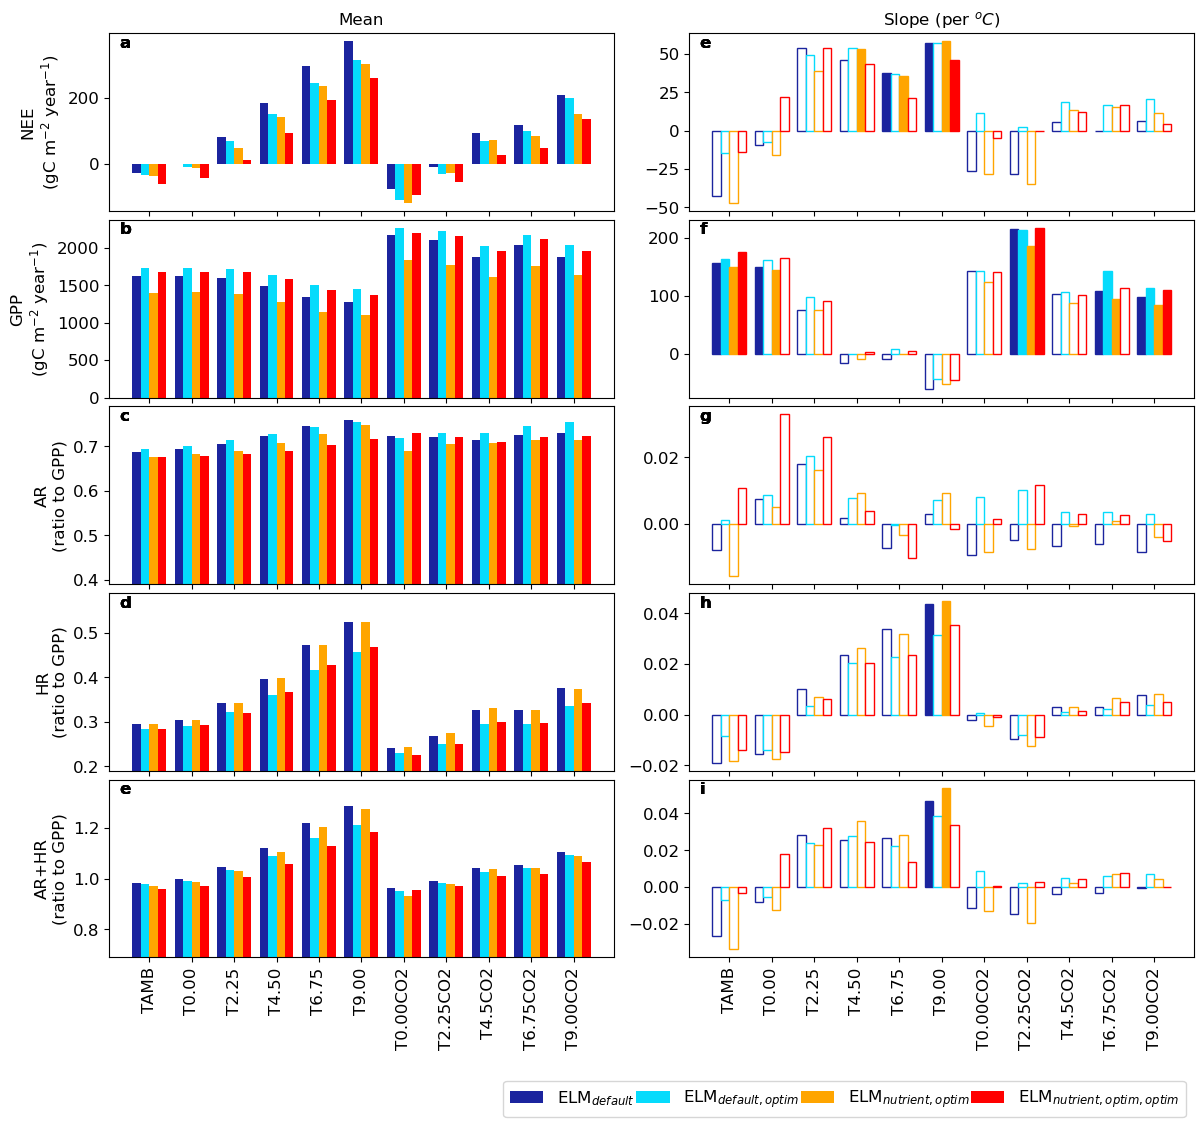

In [55]:
##########################################################################
# GPP, AR, HR, NEE
##########################################################################
fig, axes = plt.subplots(5, 2, figsize = (14, 12), sharex = True, sharey = False)
fig.subplots_adjust(hspace = 0.05, wspace = 0.15)
for i, varname in enumerate(['NEE','GPP','AR','HR','AR+HR']):

    bp = [None] * len(prefix_list)
    for p, prefix in enumerate(prefix_list):
        # Modeled values
        if varname != 'AR+HR':
            temp = collection_gs[prefix].loc[:, (slice(None), varname, '0')
                ].resample('1Y').mean().loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
            temp.columns = temp.columns.get_level_values(0)
            temp = temp * 365 * 86400
        else:
            temp = (collection_gs[prefix].loc[:, (slice(None), 'AR', '0')] + 
                    collection_gs[prefix].loc[:, (slice(None), 'HR', '0')].values).resample('1Y').mean().loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
            temp.columns = temp.columns.get_level_values(0)
            temp = temp * 365 * 86400

        # average
        temp_mean = temp.mean(axis = 0)

        if varname != 'NEE' and varname != 'GPP':
            # calculate the ratio to GPP for AR & HR
            temp2 = collection_gs[prefix].loc[:, (slice(None), 'GPP', '0')
                ].resample('1Y').mean().loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
            temp2.columns = temp2.columns.get_level_values(0)
            temp2 = temp2 * 365 * 86400

            temp = temp / temp2.values
            temp_mean = temp_mean / temp2.mean(axis = 0)


        ax = axes[i,0]
        bp[p] = ax.bar(height = temp_mean, x = np.arange(temp.shape[1]) + p*0.8/len(prefix_list),
                       width = 0.8/len(prefix_list), facecolor = color_list[p])
        ax.set_xlabel(None)
        if varname == 'NEE' or varname == 'GPP':
            ax.set_ylabel(varname + '\n(gC m$^{-2}$ year$^{-1}$)')
        else:
            ax.set_ylabel(varname + '\n(ratio to GPP)')
        if i == 0:
            ax.set_title('Mean')
        ax.set_xticks(np.arange(temp.shape[1]) + 0.3)
        ax.set_xticklabels(xticklabels, rotation = 90)
        ax.text(0.02, 0.92, labs[i], transform = ax.transAxes, fontdict = {'weight': 'bold'})

        if varname == 'AR':
            ax.set_ylim([0.39, 0.79])
        if varname == 'HR':
            ax.set_ylim([0.19, 0.59])
        if varname == 'AR+HR':
            ax.set_ylim([0.69, 1.39])

        # correlation with air temperature
        temp2 = collection_gs[prefix].loc[:, (slice(None), 'TBOT', '0')
            ].loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
        temp2.columns = temp2.columns.get_level_values(0)
        temp2 = temp2.resample('1Y').mean()

        temp_slope = pd.Series(np.nan, index = temp2.columns)
        temp_slope_p = pd.Series(np.nan, index = temp2.columns)
        for col in temp2.columns:
            filt = ~(np.isnan(temp2[col]) | np.isnan(temp[col]))
            res = linregress(temp2.loc[filt, col], temp.loc[filt, col])
            temp_slope.loc[col] = res.slope
            temp_slope_p.loc[col] = res.pvalue

        ax = axes[i,1]
        bar_list = ax.bar(height = temp_slope,
                        x = np.arange(temp.shape[1]) + p*0.8/len(prefix_list),
                        width = 0.8/len(prefix_list), facecolor = color_list[p], 
                        edgecolor = color_list[p])
        for b,bar in enumerate(bar_list):
            if temp_slope_p.values[b] >= 0.05:
                bar.set_facecolor('w')
        if i == 0:
            ax.set_title('Slope (per $^{o}C$)')
        ax.set_xticks(np.arange(temp.shape[1]) + 0.3)
        ax.set_xticklabels(xticklabels, rotation = 90)
        ax.text(0.02, 0.92, labs[4+i], transform = ax.transAxes, fontdict = {'weight': 'bold'})

    if i == 4:
        ax.legend(bp, name_list, loc='upper right', 
                  ncol = 4, bbox_to_anchor = (1, -0.65), columnspacing = 0.1)

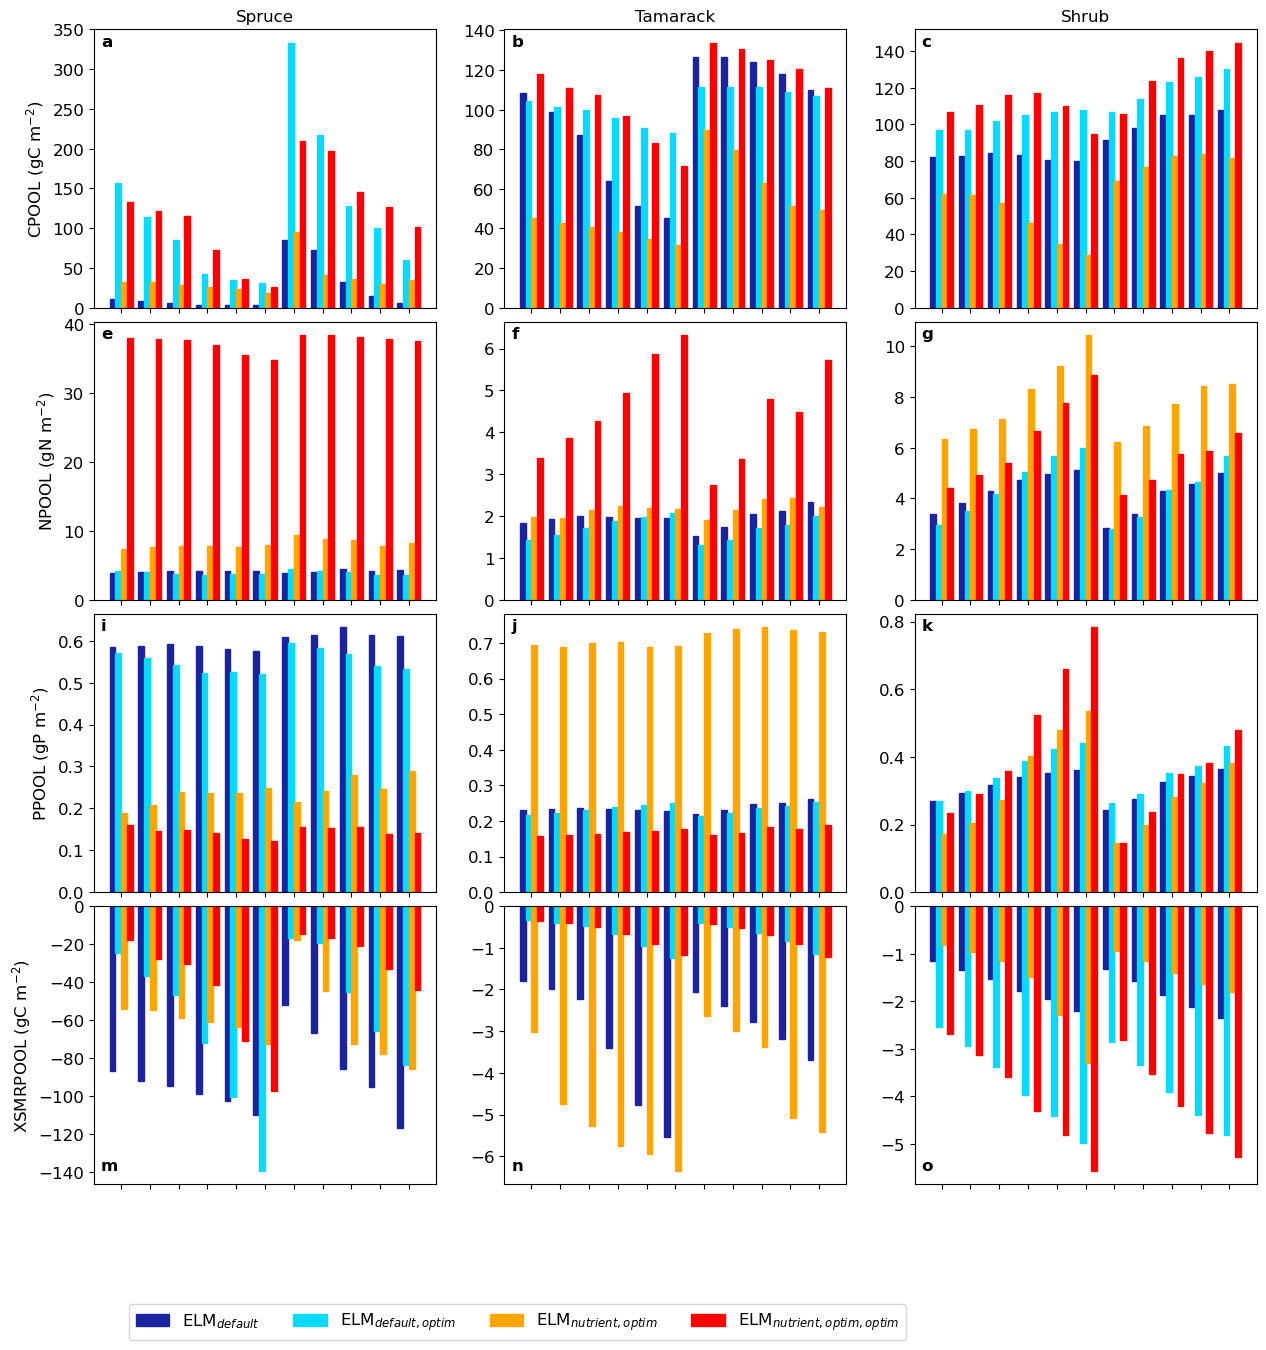

In [7]:
##########################################################################
# CPOOL & NPOOL & PPOOL sizes
##########################################################################
fig, axes = plt.subplots(4, 3, figsize = (15, 15), sharex = True, sharey = False)
fig.subplots_adjust(hspace = 0.05)
for n, nu in enumerate(['C','N','P','XSMR']):
    for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
        ax = axes[n, i]

        bar_list = [None] * len(prefix_list)
        for p, (prefix, color) in enumerate(zip(prefix_list, color_list)):
            temp = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
                ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
            xpool = temp.loc[:, (pft, f'{nu}POOL')] * pft_frac[i]
            bar_list[p] = ax.bar(np.arange(len(xpool)) + p*0.8/len(prefix_list), 
                                 xpool, facecolor = color, edgecolor = color, 
                                 width = 0.8/len(prefix_list))

        if i == 0:
            if nu == 'XSMR':
                ax.set_ylabel(f'{nu}POOL (gC' + ' m$^{-2}$)')
            else:
                ax.set_ylabel(f'{nu}POOL (g{nu}' + ' m$^{-2}$)')
        if n == 0:
            ax.set_title(name)

        ax.set_xticks(np.arange(len(xpool)) + 0.3)
        if n == 2:
            ax.set_xticklabels(xticklabels, rotation = 90)
        else:
            ax.set_xticklabels([])
        ax.set_xlabel(None)

        if nu == 'XSMR':
            ax.text(0.02, 0.05, labs[n*len(prefix_list) + i], transform = ax.transAxes, 
                    fontdict = {'weight': 'bold'})
        else:
            ax.text(0.02, 0.94, labs[n*len(prefix_list) + i], transform = ax.transAxes, 
                    fontdict = {'weight': 'bold'})
ax.legend(bar_list, name_list, ncol = 4, bbox_to_anchor = (0, -0.4))

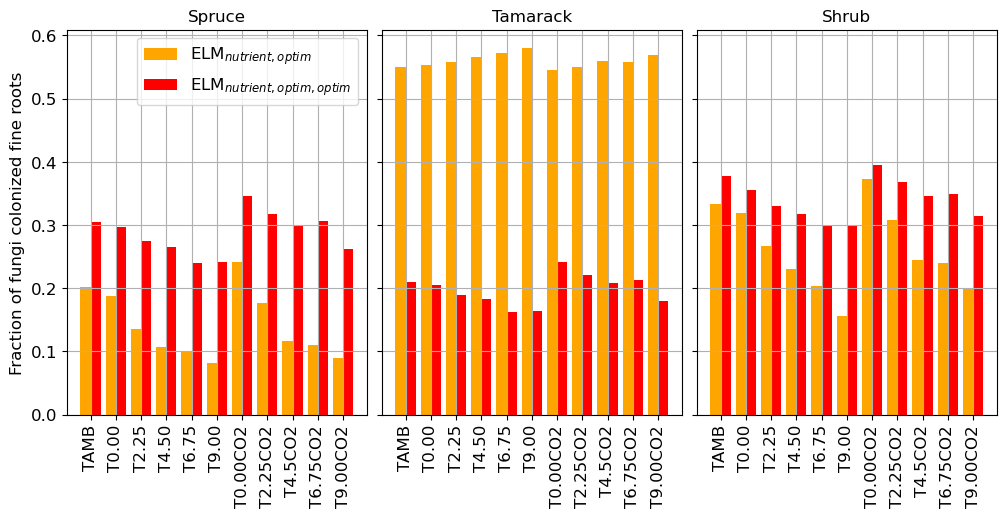

In [8]:
##########################################################################
# Fungi inhibition on nutrient uptake
# !!!!!!!!!!!!!!!!!!!! Need to add uncertainty intervals !!!!!!!!!!!!!!!!
##########################################################################
fig, axes = plt.subplots(1, 3, figsize = (12, 5), sharex = True, sharey = True)
fig.subplots_adjust(wspace = 0.05)
for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
    ax = axes.flat[i]

    bar_list = [None] * len(prefix_list[2:])
    for p, (prefix, color) in enumerate(zip(prefix_list[2:], color_list[2:])):

        temp = collection_gs[prefix].loc[:, (slice(None), 'FUNGI_INHIB_PATCH', pft)
            ].resample('1Y').mean().loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
        temp.columns = temp.columns.get_level_values(0)
        bar_list[p] = ax.bar(np.arange(temp.shape[1]) + p*0.8/2, 
                             np.mean(temp, axis = 0), width = 0.8/2, facecolor = color)

    if i == 0:
        ax.set_ylabel('Fraction of fungi colonized fine roots')
    if i == 0:
        ax.legend(bar_list, name_list[2:])
    ax.set_xticks(np.arange(temp.shape[1]) + 0.4/2)
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_xlabel(None)
    ax.set_title(name)
    ax.grid(True)

/tmp/ipykernel_3849497/4118232835.py:58: UserWarning: Legend does not support handles for NoneType instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend(bar_list + hatch_list, name_list + ['XR','MR','GR','CPOOL_TO_FUNGI'],


(0.0, 1.0, 0.0, 1.0)

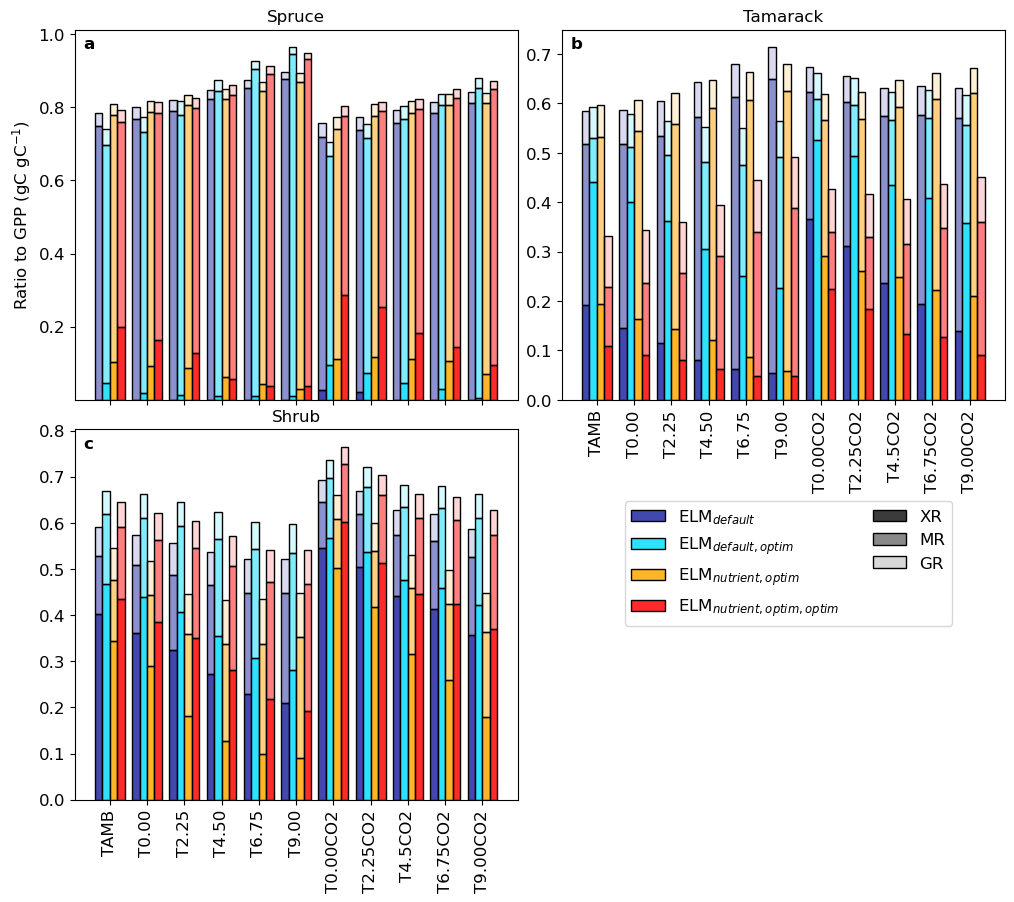

In [65]:
##########################################################################
# GPP loss via various pathways
##########################################################################
fig, axes = plt.subplots(2, 2, figsize = (12, 10), sharex = False, sharey = False)
fig.subplots_adjust(wspace = 0.1, hspace = 0.08)
for i, (pft, pname) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
    ax = axes.flat[i]

    bar_list = [None] * len(prefix_list)
    for j, (prefix, name, color) in enumerate(zip(prefix_list, name_list, color_list)):

        temp = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
            ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
        xxr = temp.loc[:, (pft, 'XR')] / temp.loc[:, (pft, 'GPP')]
        mr = temp.loc[:, (pft, 'MR')] / temp.loc[:, (pft, 'GPP')]
        gr = temp.loc[:, (pft, 'GR')] / temp.loc[:, (pft, 'GPP')]

        #if 'default' in name:
        retemp = pd.concat([xxr, mr, gr], axis = 1)
        retemp.columns = ['XR', 'MR', 'GR']
        #else:
        #    cpool_to_fungi = temp.loc[:, (pft, 'CPOOL_TO_FUNGI')] / temp.loc[:, (pft, 'GPP')]
        #    retemp = pd.concat([xxr, mr, gr, cpool_to_fungi], axis = 1)
        #    retemp.columns = ['XR', 'MR', 'GR', 'CPOOL_TO_FUNGI']

        bottom = 0
        for c, col in enumerate(retemp.columns):
            if c < 3:
                colr = to_rgba(color, max(1 - (c+0.5)/3, 0))
                bar = ax.bar(np.arange(retemp.shape[0]) + j*0.8/4, retemp[col], color = colr, 
                             edgecolor = 'k', bottom = bottom, width = 0.8/4)
            else:
                bar = ax.bar(np.arange(retemp.shape[0]) + j*0.8/4, retemp[col], color = 'w', 
                             edgecolor = 'k', bottom = bottom, width = 0.8/4)
            if (c == 0):
                bar_list[j] = bar
            bottom = bottom + retemp[col]

        if not 'default' in name:
            hatch_list = [None] * 4
            for c, col in enumerate(retemp.columns):
                if c < 3:
                    colr = to_rgba('#141414', max(1 - (c+0.5)/3, 0))
                    bar = ax.bar(np.nan, np.nan, color = colr, edgecolor = 'k')
                else:
                    bar = ax.bar(np.nan, np.nan, color = 'w', edgecolor = 'k')
                hatch_list[c] = bar

    ax.text(0.02, 0.95, labs[i], fontdict={'weight':'bold'}, transform=ax.transAxes)
    ax.set_title(pname)
    ax.set_xticks(np.arange(retemp.shape[0]) + 0.3)
    if i == 0:
        ax.set_xticklabels([])
    else:
        ax.set_xticklabels(xticklabels, rotation = 90)
    if i == 0:
        ax.set_ylabel('Ratio to GPP (gC gC$^{-1}$)')
        ax.legend(bar_list + hatch_list, name_list + ['XR','MR','GR','CPOOL_TO_FUNGI'], 
                  ncol = 2, bbox_to_anchor = (2, -0.25))

axes.flat[-1].axis('off')

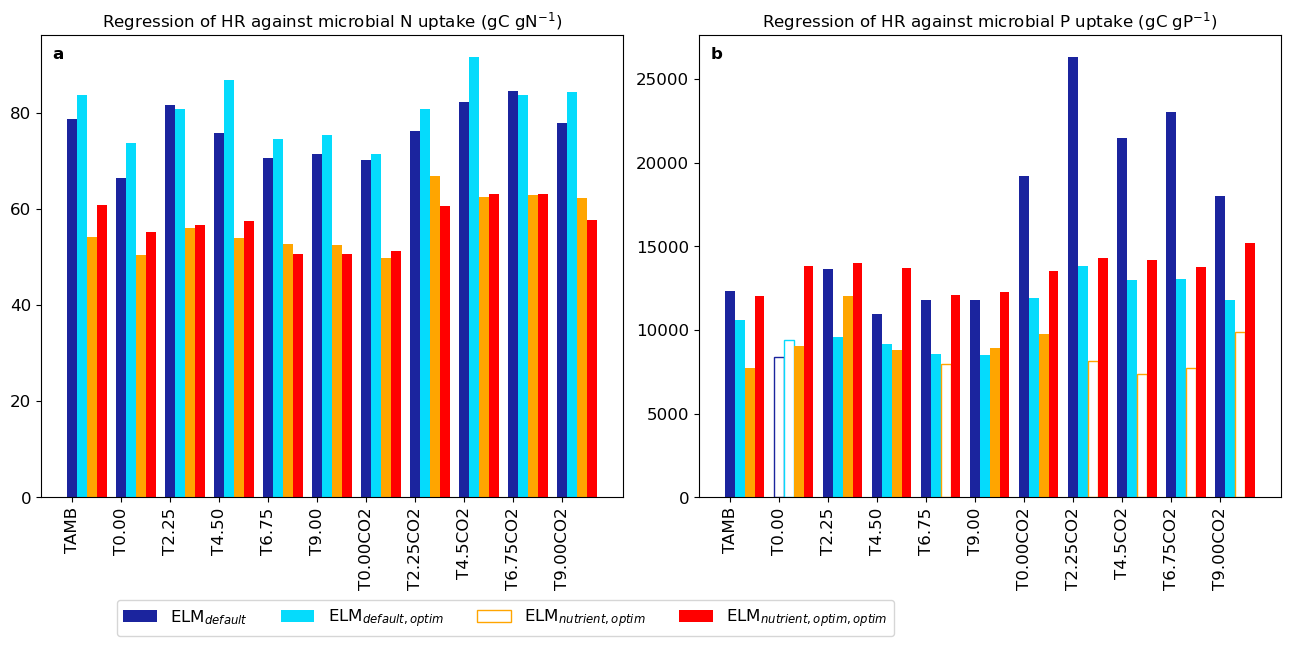

In [10]:
# N requirement per unit HR
fig, axes = plt.subplots(1, 2, figsize = (16, 6))
fig.subplots_adjust(wspace = 0.13)
for i, (varname, varname2, nu) in enumerate(zip(
    ['ACTUAL_IMMOB', 'ACTUAL_IMMOB_P'],
    ['FPI', 'FPI_P'], ['N', 'P']
)):
    ax = axes.flat[i]

    bp = [None] * len(prefix_list)
    for j, (prefix, name, color) in enumerate(zip(prefix_list, name_list, color_list)):
        slopes = pd.DataFrame(np.nan, index = chambers_ordered['amb'] + chambers_ordered['elev'],
                              columns = ['slope', 'pval'])
        for col in chambers_ordered['amb'] + chambers_ordered['elev']:
            x = collection_gs[prefix].loc[:, (col, varname, '0')].resample('1Y').mean() * 86400
            y = collection_gs[prefix].loc[:, (col, 'HR', '0')].resample('1Y').mean() * 86400
            res = linregress(x, y)
            slopes.loc[col, 'slope'] = res.slope
            slopes.loc[col, 'pval'] = res.pvalue

        for c, col in enumerate(slopes.index):
            if slopes.loc[col,'pval'] <= 0.05:
                facecolor = color
                edgecolor = 'none'
            else:
                facecolor = 'w'
                edgecolor = color
            bp[j] = ax.bar(height = slopes.loc[col,'slope'], x = c + j*0.8/len(prefix_list),
                           width = 0.8/len(prefix_list), facecolor = facecolor, 
                           edgecolor = edgecolor)

        ax.set_xticks(range(slopes.shape[0]))
        ax.set_xticklabels(xticklabels, rotation = 90)

        ax.set_title(f'Regression of HR against microbial {nu} uptake (gC g{nu}' + '$^{-1}$)')
    ax.text(0.02, 0.95, labs[i], fontdict = {'weight': 'bold'}, transform = ax.transAxes)

ax.legend(bp, name_list, ncol = 4, loc = (-1, -0.3))